# fixed-CO2 metrics benchmark notebook with uncertainty bands

This notebook extends the unified **fixed-CO$_2$ approach** workflow to include:
- central trajectories from the point-value sheets
- uncertainty envelopes from the `*_wh_ensmb_*` sheets
- flexible band options:
  - percentile band, e.g. P5–P95
  - absolute min/max across the 1001 ensemble

It supports three metric families through one selector:
- `gwp`
- `rf`
- `agwp`

For `METRIC_KIND = "gwp"`, the notebook computes fixed-CO$_2$ dpGWP from AGWP:
`dpGWP = AGWP_gas / AGWP_CO2_fixed`.
The same denominator is applied to every ensemble member.


In [1]:
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'Times New Roman'
matplotlib.style.use('tableau-colorblind10')


## configuration

In [2]:
# ---- choose metric family here ----
METRIC_KIND = "gwp"   # options: "gwp", "rf", "agwp"
EXPORT_OUTPUTS = False


# ---- uncertainty band configuration ----
UNCERTAINTY_MODE = "percentile"   # options: "percentile", "minmax"
P_LOW = 5
P_HIGH = 95
BAND_ALPHA = 0.12
LINEWIDTH = 1.8



# horizon setup
len_cf = 101
HORIZON_YEARS = np.arange(len_cf)

# scenarios and model years
ssps = ["119", "245", "585"]
MYs = [2030, 2040, 2050]
ghggass = ["CO2", "CH4", "N2O"]

# metric directories
metric_dir_modB = "../FaIR_dpCFs/output/metrics_2026-02-23/"
metric_dir_modC = "../FaIR_dpCFs/output/metrics_AGWP_wh_ModC_CC_T/"

# workbook naming template
filename_template_modB = "agwp_dcf_gwp100_tstep1{gas}_ssp{ssp}_fair_start1750MY{MY}.xlsx"
filename_template_modC = "agwp_by_pIRF_tstep1{gas}_ssp{ssp}_fair_start1750MY{MY}.xlsx"

# fixed-CO2 denominator
agwp_co2_fixed_file = "../AGWPCO2_fixed_IPCCAR6/AGWP_CO2_fixed.xlsx"
agwp_co2_fixed_col = "AGWP_CO2_fixed"

# plotting style
ssp_labels = {"119": "SSP1-1.9", "245": "SSP2-4.5", "585": "SSP5-8.5"}
ssp_colors = {"119": "#43dde6", "245": "#364f6b", "585": "#fc5185"}


In [3]:
def get_metric_meta(metric_kind: str):
    metric_kind = metric_kind.lower()

    if metric_kind == "gwp":
        return {
            "sheet_template": "agwp_pointvalue{gas}_{MY}",
            "ensmb_sheet_template": "agwp_wh_ensmb_{gas}{MY}",
            "suffix": "GWP",
            "value_label": "dpGWP",
            "panel_ylabel": "dpGWP (fixed CO$_2$ 2s)",
            "suptitle": "Benchmark of fixed-CO$_2$ dpGWP metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)",
            "export_stub": "dpGWP_fixedCO2",
            "nc_stub": "GWP",
            "needs_fixed_co2_denominator": True,
        }
    elif metric_kind == "rf":
        return {
            "sheet_template": "rf_pointvalue{gas}_{MY}",
            "ensmb_sheet_template": "rf_wh_ensmb_{gas}{MY}",
            "suffix": "RF",
            "value_label": "instantaneous RF",
            "panel_ylabel": "Instantaneous RF",
            "suptitle": "Benchmark of fixed-CO$_2$ instantaneous RF metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)",
            "export_stub": "dRF_fixedCO2",
            "nc_stub": "RF",
            "needs_fixed_co2_denominator": False,
        }
    elif metric_kind == "agwp":
        return {
            "sheet_template": "agwp_pointvalue{gas}_{MY}",
            "ensmb_sheet_template": "agwp_wh_ensmb_{gas}{MY}",
            "suffix": "AGWP",
            "value_label": "cumulative RF",
            "panel_ylabel": "Cumulative RF",
            "suptitle": "Benchmark of fixed-CO$_2$ cumulative RF metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)",
            "export_stub": "dCRF_fixedCO2",
            "nc_stub": "CRF",
            "needs_fixed_co2_denominator": False,
        }
    else:
        raise ValueError("METRIC_KIND must be one of: 'gwp', 'rf', 'agwp'")


META = get_metric_meta(METRIC_KIND)
META

{'sheet_template': 'agwp_pointvalue{gas}_{MY}',
 'ensmb_sheet_template': 'agwp_wh_ensmb_{gas}{MY}',
 'suffix': 'GWP',
 'value_label': 'dpGWP',
 'panel_ylabel': 'dpGWP (fixed CO$_2$ 2s)',
 'suptitle': 'Benchmark of fixed-CO$_2$ dpGWP metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)',
 'export_stub': 'dpGWP_fixedCO2',
 'nc_stub': 'GWP',
 'needs_fixed_co2_denominator': True}

## helper functions

In [4]:

def _read_numeric_vector_from_pointvalue(cf_file, sheet_name, gas, len_cf=101):
    cf_df = pd.read_excel(cf_file, sheet_name=sheet_name)
    if gas in cf_df.columns:
        vals = pd.to_numeric(cf_df[gas], errors="coerce").to_numpy()
    else:
        # fall back to first numeric column
        num_df = cf_df.apply(pd.to_numeric, errors="coerce")
        vals = num_df.select_dtypes(include=[np.number]).iloc[:, 0].to_numpy()
    return np.asarray(vals[:len_cf], dtype=float)


def _read_numeric_matrix_from_ensemble(cf_file, sheet_name, len_cf=101):
    ens_df = pd.read_excel(cf_file, sheet_name=sheet_name, index_col=0)
    ens_df = ens_df.apply(pd.to_numeric, errors="coerce")
    ens_df = ens_df.dropna(axis=1, how="all")
    mat = ens_df.to_numpy(dtype=float)

    if mat.shape[0] < len_cf and mat.shape[1] >= len_cf:
        mat = mat.T

    if mat.shape[0] < len_cf:
        raise ValueError(f"{cf_file.name}::{sheet_name} has only {mat.shape[0]} rows; expected at least {len_cf}")

    return np.asarray(mat[:len_cf, :], dtype=float)


def load_metric_pointvalue_dict(metric_dir, filename_template, ghg_list, ssps, MYs, sheet_template, len_cf=101):
    metric_dir = Path(metric_dir)
    out = defaultdict(lambda: defaultdict(dict))

    for gas in ghg_list:
        for sp in ssps:
            for MY in MYs:
                cf_file = metric_dir / filename_template.format(gas=gas, ssp=sp, MY=MY)
                sheet_name = sheet_template.format(gas=gas, MY=MY)
                out[gas][f"ssp{sp}"][str(MY)] = _read_numeric_vector_from_pointvalue(
                    cf_file=cf_file, sheet_name=sheet_name, gas=gas, len_cf=len_cf
                )
    return out


def load_metric_ensemble_dict(metric_dir, filename_template, ghg_list, ssps, MYs, ensmb_sheet_template, len_cf=101):
    metric_dir = Path(metric_dir)
    out = defaultdict(lambda: defaultdict(dict))

    for gas in ghg_list:
        for sp in ssps:
            for MY in MYs:
                cf_file = metric_dir / filename_template.format(gas=gas, ssp=sp, MY=MY)
                sheet_name = ensmb_sheet_template.format(gas=gas, MY=MY)
                out[gas][f"ssp{sp}"][str(MY)] = _read_numeric_matrix_from_ensemble(
                    cf_file=cf_file, sheet_name=sheet_name, len_cf=len_cf
                )
    return out


def build_metric_dataframe(metric_results, metric_suffix, strip_ssp_prefix=False, integer_dims=False, prepend_zero_row=False):
    records = []

    ref_gas = list(metric_results.keys())[0]
    for ssp in metric_results[ref_gas].keys():
        for my in metric_results[ref_gas][ssp].keys():
            arr_len = len(metric_results[ref_gas][ssp][my])

            if prepend_zero_row:
                row0 = {"SSP": ssp, "ModelYear": my, "Year": 0}
                for gas in metric_results.keys():
                    row0[f"{gas}_{metric_suffix}"] = 0.0
                records.append(row0)
                year_start = 1
            else:
                year_start = 0

            for i in range(arr_len):
                row = {"SSP": ssp, "ModelYear": my, "Year": year_start + i}
                for gas in metric_results.keys():
                    row[f"{gas}_{metric_suffix}"] = metric_results[gas][ssp][my][i]
                records.append(row)

    df_out = pd.DataFrame(records)

    if strip_ssp_prefix:
        df_out["SSP"] = df_out["SSP"].astype(str).str.replace("ssp", "", regex=False)

    if integer_dims:
        df_out["ModelYear"] = pd.to_numeric(df_out["ModelYear"], errors="coerce").astype(int)
        df_out["Year"] = pd.to_numeric(df_out["Year"], errors="coerce").astype(int)

    return df_out.set_index(["SSP", "ModelYear", "Year"]).sort_index()



def build_uncertainty_long_df(metric_ensemble_results, metric_suffix, prepend_zero_row=False):
    records = []
    ref_gas = list(metric_ensemble_results.keys())[0]

    for ssp in metric_ensemble_results[ref_gas].keys():
        for my in metric_ensemble_results[ref_gas][ssp].keys():
            mat_ref = np.asarray(metric_ensemble_results[ref_gas][ssp][my], dtype=float)
            n_years, n_ens = mat_ref.shape

            if prepend_zero_row:
                for gas in metric_ensemble_results.keys():
                    records.append({
                        "SSP": ssp.replace("ssp", ""),
                        "ModelYear": int(my),
                        "Year": 0,
                        "Gas": gas,
                        "lower": 0.0,
                        "upper": 0.0,
                        "central": 0.0,
                        "n_ens": int(n_ens),
                    })
                year_offset = 1
            else:
                year_offset = 0

            for gas in metric_ensemble_results.keys():
                mat = np.asarray(metric_ensemble_results[gas][ssp][my], dtype=float)

                for i in range(mat.shape[0]):
                    vals = np.asarray(mat[i, :], dtype=float)
                    vals = vals[np.isfinite(vals)]

                    if vals.size == 0:
                        lower = np.nan
                        upper = np.nan
                        central = np.nan
                        n_eff = 0
                    else:
                        if UNCERTAINTY_MODE == "percentile":
                            lower = float(np.nanpercentile(vals, P_LOW))
                            upper = float(np.nanpercentile(vals, P_HIGH))
                        elif UNCERTAINTY_MODE == "minmax":
                            lower = float(np.nanmin(vals))
                            upper = float(np.nanmax(vals))
                        else:
                            raise ValueError("UNCERTAINTY_MODE must be 'percentile' or 'minmax'")

                        central = float(np.nanmedian(vals))
                        n_eff = int(vals.size)

                    records.append({
                        "SSP": ssp.replace("ssp", ""),
                        "ModelYear": int(my),
                        "Year": int(year_offset + i),
                        "Gas": gas,
                        "lower": lower,
                        "upper": upper,
                        "central": central,
                        "n_ens": n_eff,
                    })

    df = pd.DataFrame(records).sort_values(["Gas", "SSP", "ModelYear", "Year"]).reset_index(drop=True)

    for col in ["ModelYear", "Year", "lower", "upper", "central", "n_ens"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["ModelYear"] = df["ModelYear"].astype("Int64")
    df["Year"] = df["Year"].astype("Int64")
    df["n_ens"] = df["n_ens"].astype("Int64")

    return df



def export_metric_outputs(df_formatted, out_dir, excel_name, nc_name_full, nc_name_hpos):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    df_formatted.to_excel(out_dir / excel_name, index=True)

    xr_full = df_formatted.to_xarray()
    xr_full.to_netcdf(out_dir / nc_name_full)

    df_hpos = df_formatted[~(df_formatted.index.get_level_values("Year") == 0)].copy()
    xr_hpos = df_hpos.to_xarray()
    xr_hpos.to_netcdf(out_dir / nc_name_hpos)

    return df_hpos, xr_full, xr_hpos


def wide_to_long_for_benchmark(df_wide, metric_suffix, value_label, approach_name):
    value_cols = [f"CO2_{metric_suffix}", f"CH4_{metric_suffix}", f"N2O_{metric_suffix}"]

    long_df = (
        df_wide
        .reset_index()
        .melt(
            id_vars=["SSP", "ModelYear", "Year"],
            value_vars=value_cols,
            var_name="Gas",
            value_name=value_label,
        )
    )
    long_df["Gas"] = long_df["Gas"].str.replace(f"_{metric_suffix}", "", regex=False)
    long_df["Approach"] = approach_name
    return long_df


def standardize_benchmark_keys(df_long):
    df_long = df_long.copy()
    df_long["SSP"] = df_long["SSP"].astype(str).str.strip().str.replace("ssp", "", regex=False)
    df_long["Gas"] = df_long["Gas"].astype(str).str.strip()
    df_long["ModelYear"] = pd.to_numeric(df_long["ModelYear"], errors="coerce").astype("Int64")
    df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce").astype("Int64")
    return df_long


def build_benchmark_dataframe(df_modB, df_modC, metric_suffix, value_label):
    long_modB = standardize_benchmark_keys(
        wide_to_long_for_benchmark(df_modB, metric_suffix=metric_suffix, value_label=value_label, approach_name="Module B")
    )
    long_modC = standardize_benchmark_keys(
        wide_to_long_for_benchmark(df_modC, metric_suffix=metric_suffix, value_label=value_label, approach_name="Module C")
    )

    bench = (
        long_modB
        .merge(
            long_modC,
            on=["SSP", "ModelYear", "Year", "Gas"],
            suffixes=("_ModB", "_ModC"),
            how="inner",
            validate="one_to_one",
        )
        .drop(columns=["Approach_ModB", "Approach_ModC"])
    )

    bench["abs_diff"] = bench[f"{value_label}_ModC"] - bench[f"{value_label}_ModB"]
    bench["abs_diff_abs"] = bench["abs_diff"].abs()
    bench["pct_diff_vs_ModB"] = np.where(
        bench[f"{value_label}_ModB"] != 0,
        100 * bench["abs_diff"] / bench[f"{value_label}_ModB"],
        np.nan,
    )
    bench["pct_diff_abs"] = bench["pct_diff_vs_ModB"].abs()
    return bench



def build_benchmark_uncertainty_dataframe(unc_modB, unc_modC):
    uB = standardize_benchmark_keys(unc_modB)
    uC = standardize_benchmark_keys(unc_modC)

    bench_u = (
        uB.merge(
            uC,
            on=["SSP", "ModelYear", "Year", "Gas"],
            suffixes=("_ModB", "_ModC"),
            how="inner",
            validate="one_to_one",
        )
    )

    for col in [
        "ModelYear", "Year",
        "lower_ModB", "upper_ModB", "central_ModB", "n_ens_ModB",
        "lower_ModC", "upper_ModC", "central_ModC", "n_ens_ModC",
    ]:
        if col in bench_u.columns:
            bench_u[col] = pd.to_numeric(bench_u[col], errors="coerce")

    bench_u["ModelYear"] = bench_u["ModelYear"].astype("Int64")
    bench_u["Year"] = bench_u["Year"].astype("Int64")

    return bench_u



def summarize_benchmark(benchmark_df, value_label):
    summary_stats = (
        benchmark_df[benchmark_df["Year"] > 0]
        .groupby(["Gas", "SSP", "ModelYear"], as_index=False)
        .agg(
            mean_ModB=(f"{value_label}_ModB", "mean"),
            mean_ModC=(f"{value_label}_ModC", "mean"),
            mean_abs_diff=("abs_diff", "mean"),
            mean_abs_diff_abs=("abs_diff_abs", "mean"),
            max_abs_diff_abs=("abs_diff_abs", "max"),
            mean_pct_diff=("pct_diff_vs_ModB", "mean"),
            max_pct_diff_abs=("pct_diff_abs", "max"),
        )
    )

    for H in [20, 50, 100]:
        tmp = benchmark_df[benchmark_df["Year"] == H][["Gas", "SSP", "ModelYear", f"{value_label}_ModB", f"{value_label}_ModC", "abs_diff", "pct_diff_vs_ModB"]].copy()
        tmp = tmp.rename(columns={
            f"{value_label}_ModB": f"ModB_H{H}",
            f"{value_label}_ModC": f"ModC_H{H}",
            "abs_diff": f"abs_diff_H{H}",
            "pct_diff_vs_ModB": f"pct_diff_H{H}",
        })
        summary_stats = summary_stats.merge(tmp, on=["Gas", "SSP", "ModelYear"], how="left")

    summary_stats = summary_stats.sort_values(["Gas", "ModelYear", "SSP"]).reset_index(drop=True)

    summary_by_gas = (
        benchmark_df[benchmark_df["Year"] > 0]
        .groupby("Gas", as_index=False)
        .agg(
            mean_ModB=(f"{value_label}_ModB", "mean"),
            mean_ModC=(f"{value_label}_ModC", "mean"),
            mean_abs_diff=("abs_diff", "mean"),
            max_abs_diff_abs=("abs_diff_abs", "max"),
            mean_pct_diff=("pct_diff_vs_ModB", "mean"),
            max_pct_diff_abs=("pct_diff_abs", "max"),
        )
    )

    return summary_stats, summary_by_gas


def _band_label():
    if UNCERTAINTY_MODE == "percentile":
        return f"P{P_LOW}–P{P_HIGH}"
    return "Min–Max"



def plot_single_metric_panels_with_uncertainty(df_metric, df_unc, ylabel, gas_order=None, my_order=None):
    gas_order = gas_order or ["CO2", "CH4", "N2O"]
    my_order = my_order or [2030, 2040, 2050]

    fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=False, sharey=False)

    df_plot = df_metric.reset_index().copy()
    for col in ["ModelYear", "Year", "value"]:
        if col in df_plot.columns:
            df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")

    df_unc_plot = df_unc.copy()
    for col in ["ModelYear", "Year", "lower", "upper", "central"]:
        if col in df_unc_plot.columns:
            df_unc_plot[col] = pd.to_numeric(df_unc_plot[col], errors="coerce")

    for r, gas in enumerate(gas_order):
        for c, my in enumerate(my_order):
            ax = axes[r, c]
            sub = df_plot[(df_plot["Gas"] == gas) & (df_plot["ModelYear"] == my)].copy()
            sub_u = df_unc_plot[(df_unc_plot["Gas"] == gas) & (df_unc_plot["ModelYear"] == my)].copy()

            for ssp in ["119", "245", "585"]:
                s = sub[sub["SSP"] == ssp].sort_values("Year")
                su = sub_u[sub_u["SSP"] == ssp].sort_values("Year")

                if s.empty:
                    continue

                color = ssp_colors[ssp]

                if not su.empty:
                    su = su.dropna(subset=["Year", "lower", "upper"]).copy()
                    su = su.sort_values("Year")

                    x = su["Year"].to_numpy(dtype=float)
                    y1 = su["lower"].to_numpy(dtype=float)
                    y2 = su["upper"].to_numpy(dtype=float)

                    if len(x) > 0:
                        ax.fill_between(x, y1, y2, color=color, alpha=BAND_ALPHA, linewidth=0)

                s = s.dropna(subset=["Year", "value"]).copy()
                x_line = s["Year"].to_numpy(dtype=float)
                y_line = s["value"].to_numpy(dtype=float)
                ax.plot(x_line, y_line, color=color, linewidth=LINEWIDTH)

            ax.set_title(f"{gas}, MY={my}", fontsize=11)
            ax.set_xlabel("Time after emission")
            if c == 0:
                ax.set_ylabel(ylabel)
            ax.grid(False)

    ssp_handles = [Line2D([0], [0], color=ssp_colors[k], lw=2, label=ssp_labels[k]) for k in ["119", "245", "585"]]
    band_handles = [Line2D([0], [0], color="black", lw=6, alpha=BAND_ALPHA, label=_band_label())]

    fig.legend(handles=ssp_handles, loc="upper center", fontsize=12, bbox_to_anchor=(0.34, 0.95),
               ncol=3, frameon=True, title="Scenario")
    fig.legend(handles=band_handles, loc="upper center", fontsize=12, bbox_to_anchor=(0.74, 0.95),
               ncol=1, frameon=True, title="Uncertainty band")

    fig.subplots_adjust(top=0.86, bottom=0.07, left=0.08, right=0.98, hspace=0.42, wspace=0.25)
    plt.show()




def plot_benchmark_3x3_with_uncertainty(benchmark_df, benchmark_unc_df, value_label, panel_ylabel, suptitle, gas_order=None, my_order=None):
    gas_order = gas_order or ["CO2", "CH4", "N2O"]
    my_order = my_order or [2030, 2040, 2050]

    fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=False, sharey=False)

    df_plot = benchmark_df.copy()
    for col in ["ModelYear", "Year", f"{value_label}_ModB", f"{value_label}_ModC"]:
        if col in df_plot.columns:
            df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")

    df_unc_plot = benchmark_unc_df.copy()
    for col in ["ModelYear", "Year", "lower_ModB", "upper_ModB", "lower_ModC", "upper_ModC"]:
        if col in df_unc_plot.columns:
            df_unc_plot[col] = pd.to_numeric(df_unc_plot[col], errors="coerce")

    for r, gas in enumerate(gas_order):
        for c, my in enumerate(my_order):
            ax = axes[r, c]
            sub = df_plot[
                (df_plot["Gas"] == gas) &
                (df_plot["ModelYear"] == my) &
                (df_plot["Year"] > 0)
            ].copy()

            sub_u = df_unc_plot[
                (df_unc_plot["Gas"] == gas) &
                (df_unc_plot["ModelYear"] == my) &
                (df_unc_plot["Year"] > 0)
            ].copy()

            for ssp in ["119", "245", "585"]:
                s = sub[sub["SSP"] == ssp].sort_values("Year")
                su = sub_u[sub_u["SSP"] == ssp].sort_values("Year")

                if s.empty:
                    continue

                color = ssp_colors[ssp]

                if not su.empty:
                    su = su.dropna(subset=["Year", "lower_ModB", "upper_ModB", "lower_ModC", "upper_ModC"]).copy()
                    su = su.sort_values("Year")

                    x = su["Year"].to_numpy(dtype=float)

                    y1_b = su["lower_ModB"].to_numpy(dtype=float)
                    y2_b = su["upper_ModB"].to_numpy(dtype=float)
                    y1_c = su["lower_ModC"].to_numpy(dtype=float)
                    y2_c = su["upper_ModC"].to_numpy(dtype=float)

                    if len(x) > 0:
                        ax.fill_between(x, y1_b, y2_b, color=color, alpha=BAND_ALPHA * 0.7, linewidth=0)
                        ax.fill_between(x, y1_c, y2_c, color=color, alpha=BAND_ALPHA, linewidth=0)

                s = s.dropna(subset=["Year", f"{value_label}_ModB", f"{value_label}_ModC"]).copy()

                x_line = s["Year"].to_numpy(dtype=float)
                y_modb = s[f"{value_label}_ModB"].to_numpy(dtype=float)
                y_modc = s[f"{value_label}_ModC"].to_numpy(dtype=float)

                ax.plot(x_line, y_modb, linestyle="--", color=color, linewidth=LINEWIDTH)
                ax.plot(x_line, y_modc, linestyle="-", color=color, linewidth=LINEWIDTH)

            ax.set_title(f"{gas}, MY={my}", fontsize=12)
            ax.set_xlabel("Time after emission")
            if c == 0:
                ax.set_ylabel(panel_ylabel)
            ax.grid(False)

    ssp_handles = [Line2D([0], [0], color=ssp_colors[k], lw=2, label=ssp_labels[k]) for k in ["119", "245", "585"]]
    method_handles = [
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="IPCC analytical IRF"),
        Line2D([0], [0], color="black", lw=2, linestyle="-", label="prospective decay"),
    ]
    band_handles = [Line2D([0], [0], color="black", lw=6, alpha=BAND_ALPHA, label=_band_label())]

    fig.legend(handles=ssp_handles, loc="upper center", fontsize=12, bbox_to_anchor=(0.25, 0.96),
               ncol=3, frameon=True, title="Scenario")
    fig.legend(handles=method_handles, loc="upper center", fontsize=12, bbox_to_anchor=(0.61, 0.96),
               ncol=2, frameon=True, title="Metric calculation")
    fig.legend(handles=band_handles, loc="upper center", fontsize=12, bbox_to_anchor=(0.86, 0.96),
               ncol=1, frameon=True, title="Uncertainty band")

    fig.suptitle(suptitle, fontsize=15)
    fig.subplots_adjust(top=0.86, bottom=0.07, left=0.08, right=0.98, hspace=0.42, wspace=0.25)
    plt.show()




def load_fixed_co2_denominator(excel_file, value_col, len_cf=101):
    df = pd.read_excel(excel_file)
    vals = pd.to_numeric(df[value_col], errors="coerce").to_numpy()
    vals = vals[:len_cf]
    denom = vals[1:len_cf]
    if len(denom) != len_cf - 1:
        raise ValueError(f"Fixed-CO2 denominator length mismatch: expected {len_cf-1}, got {len(denom)}")
    return denom


def compute_fixed_co2_gwp(metric_results_agwp, agwp_co2_fixed, len_cf=101):
    out = defaultdict(lambda: defaultdict(dict))

    for gas in metric_results_agwp:
        for ssp in metric_results_agwp[gas]:
            for my in metric_results_agwp[gas][ssp]:
                arr = np.asarray(metric_results_agwp[gas][ssp][my], dtype=float)
                arr_trimmed = arr[1:len_cf]
                out[gas][ssp][my] = arr_trimmed / agwp_co2_fixed

    return out


def compute_fixed_co2_gwp_ensemble(metric_ensemble_agwp, agwp_co2_fixed, len_cf=101):
    out = defaultdict(lambda: defaultdict(dict))

    for gas in metric_ensemble_agwp:
        for ssp in metric_ensemble_agwp[gas]:
            for my in metric_ensemble_agwp[gas][ssp]:
                mat = np.asarray(metric_ensemble_agwp[gas][ssp][my], dtype=float)
                mat_trimmed = mat[1:len_cf, :]
                out[gas][ssp][my] = mat_trimmed / agwp_co2_fixed[:, None]

    return out


## A. Module B

In [5]:
if META["needs_fixed_co2_denominator"]:
    agwp_results_modB = load_metric_pointvalue_dict(
        metric_dir=metric_dir_modB,
        filename_template=filename_template_modB,
        ghg_list=ghggass,
        ssps=ssps,
        MYs=MYs,
        sheet_template="agwp_pointvalue{gas}_{MY}",
        len_cf=len_cf,
    )
    agwp_ensmb_modB = load_metric_ensemble_dict(
        metric_dir=metric_dir_modB,
        filename_template=filename_template_modB,
        ghg_list=ghggass,
        ssps=ssps,
        MYs=MYs,
        ensmb_sheet_template="agwp_wh_ensmb_{gas}{MY}",
        len_cf=len_cf,
    )
    agwp_co2_fixed = load_fixed_co2_denominator(
        excel_file=agwp_co2_fixed_file,
        value_col=agwp_co2_fixed_col,
        len_cf=len_cf,
    )
    metric_results_modB = compute_fixed_co2_gwp(
        metric_results_agwp=agwp_results_modB,
        agwp_co2_fixed=agwp_co2_fixed,
        len_cf=len_cf,
    )
    metric_ensmb_modB = compute_fixed_co2_gwp_ensemble(
        metric_ensemble_agwp=agwp_ensmb_modB,
        agwp_co2_fixed=agwp_co2_fixed,
        len_cf=len_cf,
    )
else:
    metric_results_modB = load_metric_pointvalue_dict(
        metric_dir=metric_dir_modB,
        filename_template=filename_template_modB,
        ghg_list=ghggass,
        ssps=ssps,
        MYs=MYs,
        sheet_template=META["sheet_template"],
        len_cf=len_cf,
    )
    metric_ensmb_modB = load_metric_ensemble_dict(
        metric_dir=metric_dir_modB,
        filename_template=filename_template_modB,
        ghg_list=ghggass,
        ssps=ssps,
        MYs=MYs,
        ensmb_sheet_template=META["ensmb_sheet_template"],
        len_cf=len_cf,
    )

df_modB = build_metric_dataframe(
    metric_results=metric_results_modB,
    metric_suffix=META["suffix"],
    strip_ssp_prefix=True,
    integer_dims=True,
    prepend_zero_row=META["needs_fixed_co2_denominator"],
)

unc_modB = build_uncertainty_long_df(
    metric_ensemble_results=metric_ensmb_modB,
    metric_suffix=META["suffix"],
    prepend_zero_row=META["needs_fixed_co2_denominator"],
)
print(df_modB.shape, unc_modB.shape)
df_modB.head()


(909, 3) (2727, 8)


CO2_GWP     CH4_GWP     N2O_GWP
SSP ModelYear Year                                  
119 2030      0     0.000000    0.000000    0.000000
              1     0.945684  128.642366  170.949474
              2     0.945684  126.928209  175.554756
              3     0.945684  124.985695  179.799718
              4     0.945684  122.854093  183.662784

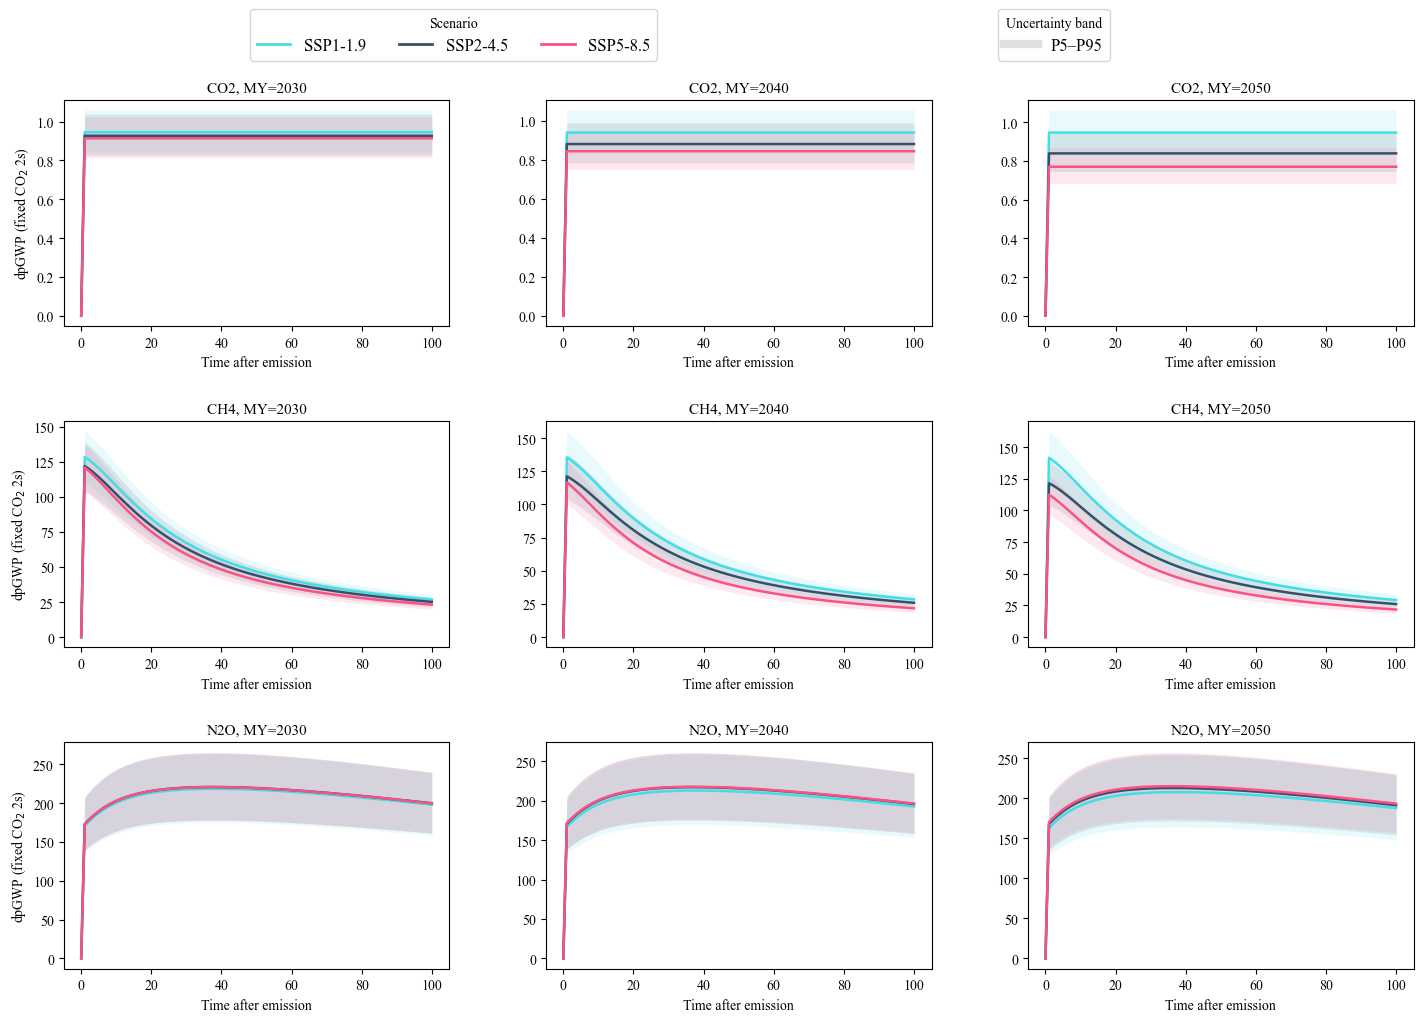

In [6]:
long_modB_preview = wide_to_long_for_benchmark(
    df_modB, metric_suffix=META["suffix"], value_label="value", approach_name="Module B"
)

plot_single_metric_panels_with_uncertainty(
    df_metric=long_modB_preview,
    df_unc=unc_modB,
    ylabel=META["panel_ylabel"],
)


## B. Module C

In [7]:
if META["needs_fixed_co2_denominator"]:
    agwp_results_modC = load_metric_pointvalue_dict(
        metric_dir=metric_dir_modC,
        filename_template=filename_template_modC,
        ghg_list=ghggass,
        ssps=ssps,
        MYs=MYs,
        sheet_template="agwp_pointvalue{gas}_{MY}",
        len_cf=len_cf,
    )
    agwp_ensmb_modC = load_metric_ensemble_dict(
        metric_dir=metric_dir_modC,
        filename_template=filename_template_modC,
        ghg_list=ghggass,
        ssps=ssps,
        MYs=MYs,
        ensmb_sheet_template="agwp_wh_ensmb_{gas}{MY}",
        len_cf=len_cf,
    )
    agwp_co2_fixed = load_fixed_co2_denominator(
        excel_file=agwp_co2_fixed_file,
        value_col=agwp_co2_fixed_col,
        len_cf=len_cf,
    )
    metric_results_modC = compute_fixed_co2_gwp(
        metric_results_agwp=agwp_results_modC,
        agwp_co2_fixed=agwp_co2_fixed,
        len_cf=len_cf,
    )
    metric_ensmb_modC = compute_fixed_co2_gwp_ensemble(
        metric_ensemble_agwp=agwp_ensmb_modC,
        agwp_co2_fixed=agwp_co2_fixed,
        len_cf=len_cf,
    )
else:
    metric_results_modC = load_metric_pointvalue_dict(
        metric_dir=metric_dir_modC,
        filename_template=filename_template_modC,
        ghg_list=ghggass,
        ssps=ssps,
        MYs=MYs,
        sheet_template=META["sheet_template"],
        len_cf=len_cf,
    )
    metric_ensmb_modC = load_metric_ensemble_dict(
        metric_dir=metric_dir_modC,
        filename_template=filename_template_modC,
        ghg_list=ghggass,
        ssps=ssps,
        MYs=MYs,
        ensmb_sheet_template=META["ensmb_sheet_template"],
        len_cf=len_cf,
    )

df_modC = build_metric_dataframe(
    metric_results=metric_results_modC,
    metric_suffix=META["suffix"],
    strip_ssp_prefix=True,
    integer_dims=True,
    prepend_zero_row=META["needs_fixed_co2_denominator"],
)

unc_modC = build_uncertainty_long_df(
    metric_ensemble_results=metric_ensmb_modC,
    metric_suffix=META["suffix"],
    prepend_zero_row=META["needs_fixed_co2_denominator"],
)
print(df_modC.shape, unc_modC.shape)
df_modC.head()


(909, 3) (2727, 8)


CO2_GWP     CH4_GWP     N2O_GWP
SSP ModelYear Year                                  
119 2030      0     0.000000    0.000000    0.000000
              1     0.941822  129.474722  170.824170
              2     0.939335  128.415469  175.169989
              3     0.940314  127.033721  179.096258
              4     0.941997  125.360343  182.631564

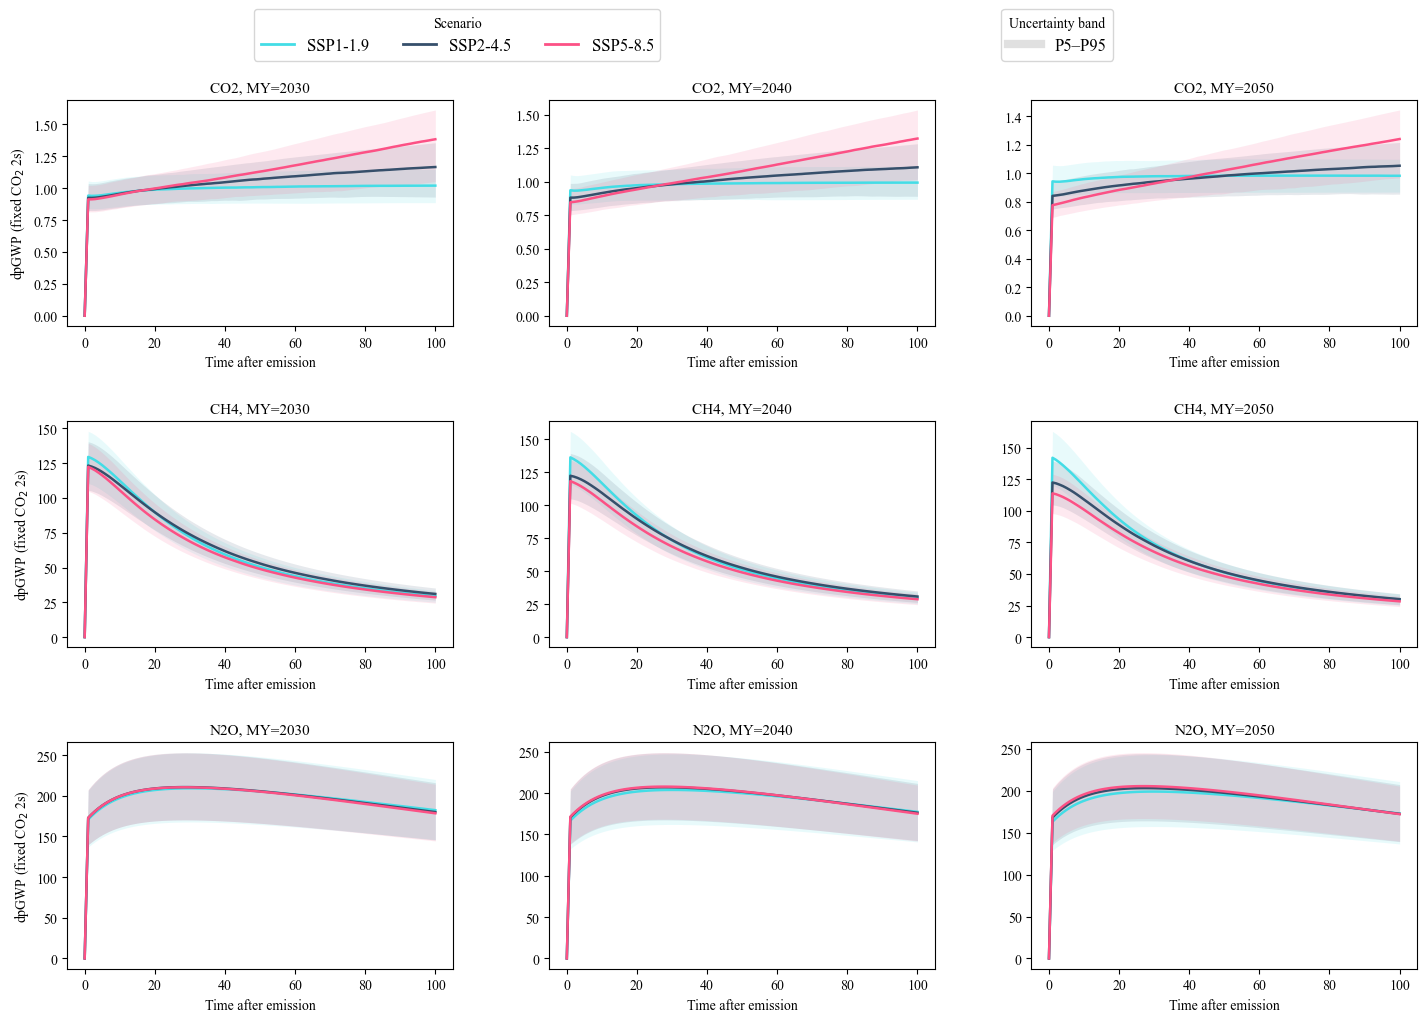

In [8]:
long_modC_preview = wide_to_long_for_benchmark(
    df_modC, metric_suffix=META["suffix"], value_label="value", approach_name="Module C"
)

plot_single_metric_panels_with_uncertainty(
    df_metric=long_modC_preview,
    df_unc=unc_modC,
    ylabel=META["panel_ylabel"],
)


## C. Benchmark Module B vs Module C

In [9]:
benchmark_df = build_benchmark_dataframe(
    df_modB=df_modB,
    df_modC=df_modC,
    metric_suffix=META["suffix"],
    value_label=META["value_label"],
)

benchmark_unc_df = build_benchmark_uncertainty_dataframe(
    unc_modB=unc_modB,
    unc_modC=unc_modC,
)

print("benchmark_df shape:", benchmark_df.shape)
print("benchmark_unc_df shape:", benchmark_unc_df.shape)
display(benchmark_df.head(12))
display(benchmark_unc_df.head(12))


benchmark_df shape: (2727, 10)
benchmark_unc_df shape: (2727, 12)


,SSP,ModelYear,Year,Gas,dpGWP_ModB,dpGWP_ModC,abs_diff,abs_diff_abs,pct_diff_vs_ModB,pct_diff_abs
0,119,2030,0,CO2,0.000000,0.000000,0.000000,0.000000,NaN,NaN
1,119,2030,1,CO2,0.945684,0.941822,-0.003862,0.003862,-0.408372,0.408372
2,119,2030,2,CO2,0.945684,0.939335,-0.006349,0.006349,-0.671315,0.671315
3,119,2030,3,CO2,0.945684,0.940314,-0.005370,0.005370,-0.567866,0.567866
4,119,2030,4,CO2,0.945684,0.941997,-0.003686,0.003686,-0.389821,0.389821
5,119,2030,5,CO2,0.945684,0.945282,-0.000402,0.000402,-0.042465,0.042465
6,119,2030,6,CO2,0.945684,0.949163,0.003479,0.003479,0.367873,0.367873
7,119,2030,7,CO2,0.945684,0.952802,0.007118,0.007118,0.752697,0.752697
8,119,2030,8,CO2,0.945684,0.956579,0.010895,0.010895,1.152112,1.152112
9,119,2030,9,CO2,0.945684,0.959903,0.014219,0.014219,1.503534,1.503534


,SSP,ModelYear,Year,Gas,lower_ModB,upper_ModB,central_ModB,n_ens_ModB,lower_ModC,upper_ModC,central_ModC,n_ens_ModC
0,119,2030,0,CH4,0.000000,0.000000,0.000000,1001,0.000000,0.000000,0.000000,1001
1,119,2030,1,CH4,109.773222,146.876181,128.642366,1001,110.503765,147.827505,129.474722,1001
2,119,2030,2,CH4,108.333433,144.911008,126.928209,1001,109.611159,146.719218,128.415469,1001
3,119,2030,3,CH4,106.685696,142.674870,124.985695,1001,108.441246,145.148898,127.033721,1001
4,119,2030,4,CH4,104.754314,140.221842,122.854093,1001,107.038937,143.263100,125.360343,1001
5,119,2030,5,CH4,102.827917,137.596184,120.570921,1001,105.366151,141.131190,123.486220,1001
6,119,2030,6,CH4,100.805910,134.848891,118.168385,1001,103.672218,138.803682,121.404347,1001
7,119,2030,7,CH4,98.711279,132.123954,115.690107,1001,101.862356,136.353110,119.266181,1001
8,119,2030,8,CH4,96.568772,129.300387,113.142575,1001,99.931566,133.781791,117.038513,1001
9,119,2030,9,CH4,94.399897,126.334306,110.562116,1001,97.968890,131.126935,114.710577,1001


In [10]:
summary_stats, summary_by_gas = summarize_benchmark(
    benchmark_df=benchmark_df,
    value_label=META["value_label"],
)

display(summary_stats)
display(summary_by_gas)


,Gas,SSP,ModelYear,mean_ModB,mean_ModC,mean_abs_diff,mean_abs_diff_abs,max_abs_diff_abs,mean_pct_diff,max_pct_diff_abs,...,abs_diff_H20,pct_diff_H20,ModB_H50,ModC_H50,abs_diff_H50,pct_diff_H50,ModB_H100,ModC_H100,abs_diff_H100,pct_diff_H100
0,CH4,119,2030,57.216604,60.792935,3.576331,3.576331,5.211713,7.227831,9.808673,...,5.165225,6.112249,46.824074,50.405750,3.581677,7.649221,26.760999,29.385897,2.624899,9.808673
1,CH4,245,2030,53.882255,61.798457,7.916202,7.916202,10.552986,17.695561,23.339348,...,10.124801,12.724486,43.971361,52.871161,8.899800,20.239992,25.136654,31.003385,5.866731,23.339348
2,CH4,585,2030,50.814048,58.178628,7.364580,7.364580,9.629426,17.750606,23.620056,...,9.217583,12.240354,40.670742,48.938155,8.267413,20.327668,23.186926,28.663690,5.476765,23.620056
3,CH4,119,2040,60.650159,62.220730,1.570571,1.570571,2.634625,2.890138,4.406730,...,2.492804,2.785231,49.750983,51.072738,1.321754,2.656740,28.469875,29.724466,1.254591,4.406730
4,CH4,245,2040,54.767825,61.459674,6.691849,6.691849,9.053613,14.455485,18.863071,...,8.836173,10.944167,45.087840,52.476685,7.388844,16.387666,25.856366,30.733670,4.877305,18.863071
5,CH4,585,2040,47.945955,57.684976,9.739022,9.739022,13.158521,24.823130,32.095536,...,12.740046,17.918601,38.071630,48.979736,10.908107,28.651536,21.721701,28.693397,6.971696,32.095536
6,CH4,119,2050,62.638699,63.063182,0.424483,0.424483,1.286884,0.690116,1.841288,...,0.786723,0.849843,51.134873,51.215832,0.080959,0.158325,29.237626,29.775975,0.538349,1.841288
7,CH4,245,2050,55.063286,60.732288,5.669003,5.669003,7.822743,12.028010,15.478696,...,7.731646,9.523567,45.366505,51.444802,6.078298,13.398206,26.051977,30.084483,4.032506,15.478696
8,CH4,585,2050,47.382765,56.685522,9.302757,9.302757,12.594906,23.667277,30.394163,...,12.399694,17.682095,37.997265,48.263120,10.265855,27.017352,21.733252,28.338891,6.605640,30.394163
9,CO2,119,2030,0.945684,1.000892,0.055208,0.055602,0.074227,5.837909,7.849037,...,0.042460,4.489830,0.945684,1.008284,0.062600,6.619523,0.945684,1.019911,0.074227,7.849037


,Gas,mean_ModB,mean_ModC,mean_abs_diff,max_abs_diff_abs,mean_pct_diff,max_pct_diff_abs
0,CH4,54.484622,60.290710,5.806089,13.158521,13.469795,32.095536
1,CO2,0.889825,1.028543,0.138719,0.478127,16.118089,61.059900
2,N2O,206.591833,194.553267,-12.038566,21.425923,-5.802664,11.072703


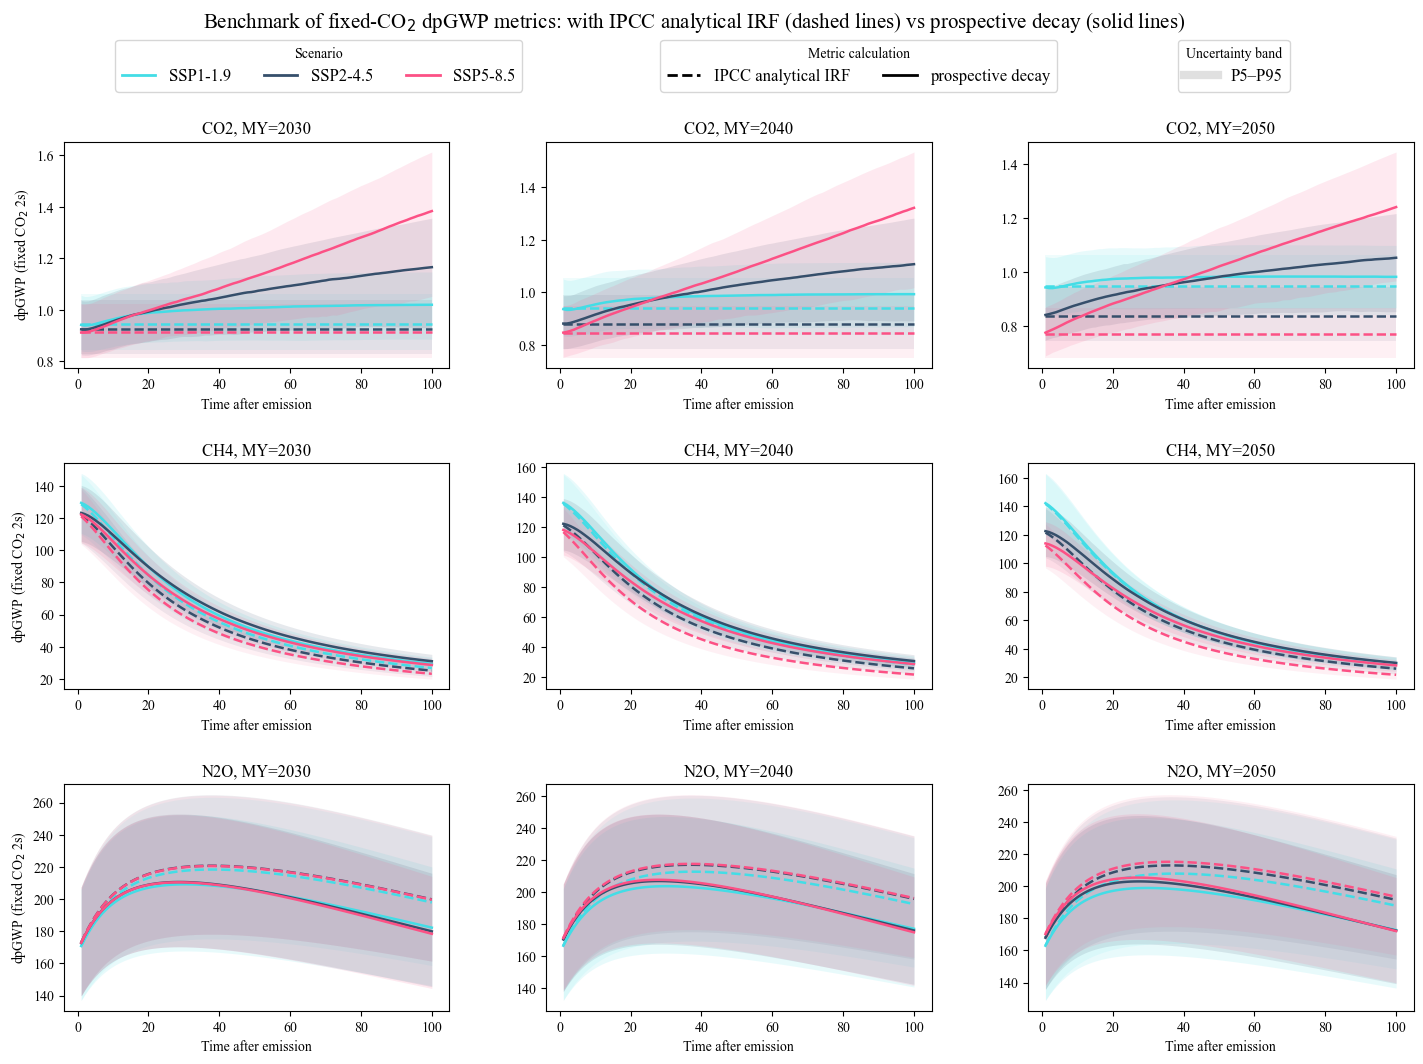

In [11]:
plot_benchmark_3x3_with_uncertainty(
    benchmark_df=benchmark_df,
    benchmark_unc_df=benchmark_unc_df,
    value_label=META["value_label"],
    panel_ylabel=META["panel_ylabel"],
    suptitle=META["suptitle"],
)


## Notes

- For `METRIC_KIND = "gwp"`, uncertainty bands are derived from the AGWP ensemble sheets
  and then converted to fixed-CO$_2$ dpGWP using the same deterministic `AGWP_CO2_fixed.xlsx`
  denominator used for the central trajectory.
- `UNCERTAINTY_MODE = "percentile"` uses `P_LOW` and `P_HIGH`.
- `UNCERTAINTY_MODE = "minmax"` uses the absolute ensemble extrema at each horizon year.
